<a href="https://colab.research.google.com/github/headdown0845/2026_First-semester/blob/main/EDA%EB%B3%B4%EA%B3%A0%EC%84%9C_%EC%98%A4%EC%A1%B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **기술통계분석을 통한 EDA보고서 - 2355022 이형민**

#**1서론**


# 1.1 분석 배경 및 목적


오존은 자동차 배기가스나 산업 시설에서 배출되는 질소산화물과 휘발성 유기화합물이 햇빛과 광화학 반응을 일으켜 생성되는 2차 오염물질입니다.
  고농도 오존은 호흡기 질환 유발, 농작물 피해 등 공중 보건과 생태계에 심각한 영향을 미칩니다.하지만 오존 농도는 기온, 습도, 풍속 등 복잡한 기상 조건과 화학적 요인들에 의해 결정되므로 단순히 한두 가지 지표만으로는 발생 여부를 예측하기 어렵습니다. 따라서 다차원적인 기상/대기 데이터를 통합적으로 분석하여 오존 발생의 패턴을 파악할 필요가 있습니다

구체적인 목적

데이터 프로파일링: 데이터의 분포와 결측치, 이상치를 파악하여 분석의 신뢰성을 확보한다.

주요 영향 인자 도출: 통계적 상관계수 분석을 통해 'Class' 결정에 가장 큰 영향을 미치는 상위 변수들을 선정한다.

패턴 시각화: 오존 발생 시점의 데이터 특징을 시각적으로 구현하여, 예측 모델 구축을 위한 기초 인사이트(Feature Engineering의 방향성)를 제공한다.

불균형 해소 전략 수립: 타겟 변수의 편향성을 확인하고, 향후 분석에서 소수 클래스(오존 발생)를 효과적으로 탐지하기 위한 전략을 제안한다.


# 1.2 데이터 셋 설명

출처 : https://www.openml.org/search?type=data&sort=runs&status=active&id=1487
(Texas Commission on Environmental Quality, TCEQ, Kun Zhang, Wei Fan, Birkavaitis)

수집 기간 : 1998~2004 (약 7년)

수집 방법 : 미국 텍사스주의 휴스턴, 갤버스턴, 브라조리아지역을 중심으로 지상 기상 관측소와 대기 측정 센서를 통해 매시간 데이터를 수집했습니다. 주요 변수로는 8시간 평균 오존 농도 피크 수치를 기준으로 오존 주의보 수준과 정상 수준을 분류한 오존 농도가 있습니다.

#1.3 주요 분석 질문

 해결하고자 하는 가설은 오존 발생일은 그렇지 않은 날에 비해 오후 시간대의 오존 농도 상승 폭이 훨씬 가파를 것이라는 가설입니다.

#**2. 데이터 프로파일링 및 기초 탐색**

# 2.1 데이터 명세 확인

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = 'ozone.csv'
df = pd.read_csv(file_path)

In [3]:
# 1. 전체 레코드 수 확인
rows, cols = df.shape
print(f"✅ 전체 레코드 수 (행): {rows:,}개")

✅ 전체 레코드 수 (행): 2,534개


In [4]:
# 2. 전체 컬럼 수 확인
print(f"✅ 전체 컬럼 수 (열): {cols:,}개")

✅ 전체 컬럼 수 (열): 73개


In [5]:
# 3. 변수 타입 확인
print("\n--- [변수 타입 확인] ---")
print(df.dtypes.value_counts())


--- [변수 타입 확인] ---
float64    72
int64       1
Name: count, dtype: int64


# 2.2 결측치 분석

In [6]:
null_count = df.isnull().sum()

In [7]:
null_percent = (null_count / len(df)) * 100

In [8]:
missing_table = pd.DataFrame({
    '결측치 개수': null_count,
    '결측치 비율(%)': null_percent
})

In [9]:
# 1. 결측치 확인
missing_counts = df.isnull().sum()
missing_ratio = (missing_counts / len(df)) * 100

In [10]:
# 2. 결과 출력 (결측치가 있는 컬럼만)
missing_df = pd.DataFrame({'Missing_Count': missing_counts, 'Ratio(%)': missing_ratio})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Ratio(%)', ascending=False)

In [11]:
if missing_df.empty:
    print("✅ 모든 컬럼에 결측치가 없습니다! (Clean Dataset)")
else:
    print("--- [결측치 발생 현황] ---")
    print(missing_df)

✅ 모든 컬럼에 결측치가 없습니다! (Clean Dataset)


/tmp/ipykernel_11278/477833229.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_ratio.index, y=missing_ratio.values, palette='Blues_r')
/tmp/ipykernel_11278/477833229.py:9: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11278/477833229.py:9: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11278/477833229.py:9: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11278/477833229.py:9: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11278/477833229.py:9: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt

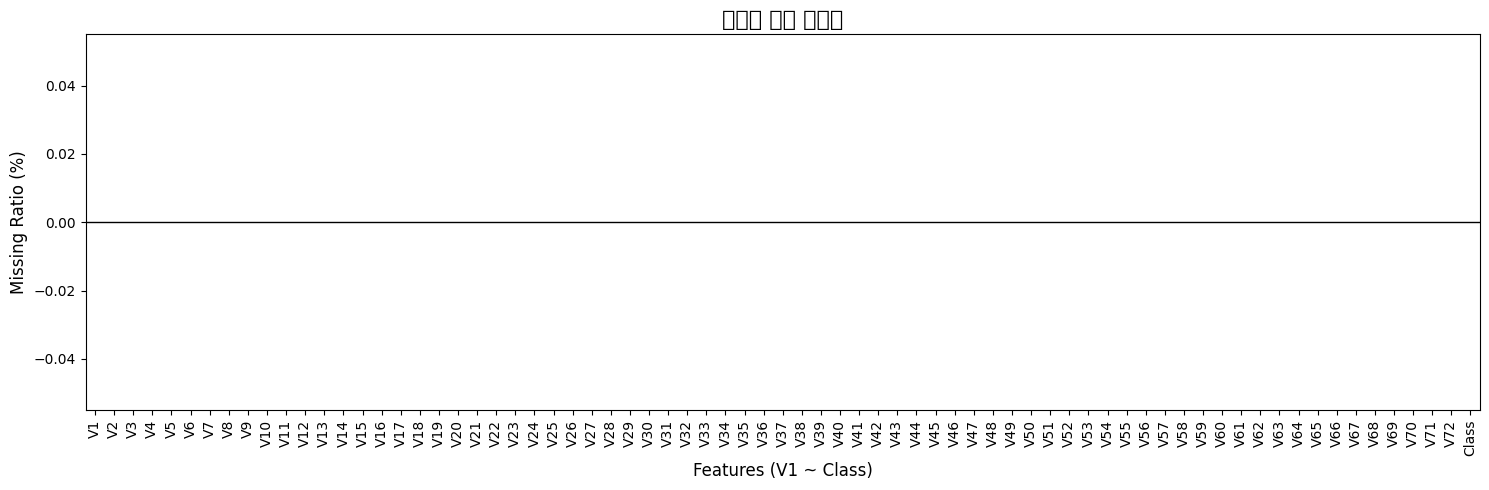

In [12]:
plt.figure(figsize=(15, 5))
sns.barplot(x=missing_ratio.index, y=missing_ratio.values, palette='Blues_r')
plt.title('결측치 비율 시각화', fontsize=16)
plt.xlabel('Features (V1 ~ Class)', fontsize=12)
plt.ylabel('Missing Ratio (%)', fontsize=12)
plt.xticks(rotation=90) # X축 변수명이 많으므로 90도 회전
plt.axhline(y=0, color='black', linestyle='-', linewidth=1) # 기준선

plt.tight_layout()
plt.show()

해당 데이터 셋은 결측치가 없는 데이터 셋이지만 만약 해당 데이터 셋에서 결측치가
발생하였다면 원인은 대기 측정 장비가 전력 이상, 자연재해로 인해
데이터를 기록하지 못하거나 비정상적인 수치가 있을 시 제거 될 수 있겠습니다.

# 2.3 기초 통계량 분석

In [13]:
stats = df.describe().T

In [14]:
stats['variance'] = df.var()
stats['median'] = df.median()

In [15]:
analysis_report = stats[['mean', 'median', 'variance', '25%', '75%']]
analysis_report.columns = ['평균(Mean)', '중앙값(Median)', '분산(Variance)', '1사분위(Q1)', '3사분위(Q3)']

In [16]:
print("--- [데이터 기초 통계량 분석] ---")
display(analysis_report.head(10))

--- [데이터 기초 통계량 분석] ---


,평균(Mean),중앙값(Median),분산(Variance),1사분위(Q1),3사분위(Q3)
V1,1.640179,1.600000,1.426992,0.8,2.200
V2,1.586351,1.500000,1.419243,0.7,2.100
V3,1.545580,1.400000,1.358743,0.7,2.100
V4,1.526405,1.400000,1.285747,0.7,2.075
V5,1.522624,1.400000,1.271308,0.7,2.000
V6,1.542417,1.400000,1.215632,0.7,2.000
V7,1.637896,1.600000,1.194236,0.8,2.100
V8,2.047127,2.047127,1.193152,1.3,2.600
V9,2.539037,2.539037,1.244224,1.8,3.200
V10,2.847708,2.847708,1.322655,2.1,3.500


In [17]:
df.mean()

,0
V1,1.640179
V2,1.586351
V3,1.545580
V4,1.526405
V5,1.522624
...,...
V69,37.388335
V70,10164.198442
V71,-0.119949
V72,0.372026


In [18]:
df.median()

,0
V1,1.600000
V2,1.500000
V3,1.400000
V4,1.400000
V5,1.400000
...,...
V69,40.500000
V70,10160.000000
V71,-0.119949
V72,0.000000


In [19]:
df.var()

,0
V1,1.426992
V2,1.419243
V3,1.358743
V4,1.285747
V5,1.271308
...,...
V69,119.882226
V70,2644.851146
V71,1203.628430
V72,1.735643


# 2.4 데이터 정제 결과

In [20]:
#1.데이터 중복 제거
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"✅ 중복 데이터 {duplicate_count}건을 제거했습니다. (현재 행: {len(df)})")
else:
    print("✅ 중복 데이터가 없습니다.")

✅ 중복 데이터 8건을 제거했습니다. (현재 행: 2526)


In [21]:
# 2. 자료형 변환
# 분석 목적에 맞게 자료형 변환
# 'Class'는 범주형(Category)으로 인식하는 것이 시각화나 모델링에 좋습니다.
df['Class'] = df['Class'].astype('category')
print("\n--- 자료형 변환 완료 ---")
print(df.dtypes.value_counts())


--- 자료형 변환 완료 ---
float64     72
category     1
Name: count, dtype: int64


In [29]:
#3. 이상치 정의 및 처리 결과
def handle_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 이상치 개수 확인
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    # 처리 방법: 여기서는 '제거(Removal)' 방식을 선택하거나,
    # 혹은 상하한선 값으로 '대체(Capping)' 할 수 있습니다. (이 코드는 제거 예시)
    cleaned_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return cleaned_data, len(outliers)

# 분석 대상 컬럼(V1)에 대해 이상치 처리 수행
df_cleaned, outlier_count = handle_outliers_iqr(df, 'V1')
print(f"\n--- 이상치 처리 결과 (V1 기준) ---")
print(f"발견된 이상치 개수: {outlier_count}개")
print(f"정제 후 데이터 크기: {df_cleaned.shape}")


--- 이상치 처리 결과 (V1 기준) ---
발견된 이상치 개수: 77개
정제 후 데이터 크기: (2449, 73)


In [31]:
df_cleaned.to_csv('cleaned_ozone_data.csv', index=False, encoding='utf-8-sig')

#**3.변수별 개별 특성 분석**

# 3.1 수치형 변수 분석

In [35]:
#수치형 변수 선택
numeric_cols = df.columns[:-1]

In [36]:
# 2. 왜도(Skewness)와 첨도(Kurtosis) 계산
# pandas의 kurt() 함수는 기본적으로 'Fisher’s definition'을 사용.
skewness = df[numeric_cols].skew()
kurtosis = df[numeric_cols].kurt()

In [37]:
normality_report = pd.DataFrame({
    '왜도(Skewness)': skewness,
    '첨도(Kurtosis)': kurtosis
})

print("--- [데이터 정규성 지표 요약 (상위 10개 변수)] ---")
display(normality_report.head(10))

--- [데이터 정규성 지표 요약 (상위 10개 변수)] ---


,왜도(Skewness),첨도(Kurtosis)
V1,1.168800,1.581325
V2,1.262546,1.956014
V3,1.271947,1.909597
V4,1.231795,1.778200
V5,1.248657,2.019385
V6,1.286351,2.152336
V7,1.242591,2.195471
V8,0.819022,1.102941
V9,0.571726,1.076544
V10,0.389323,0.575988


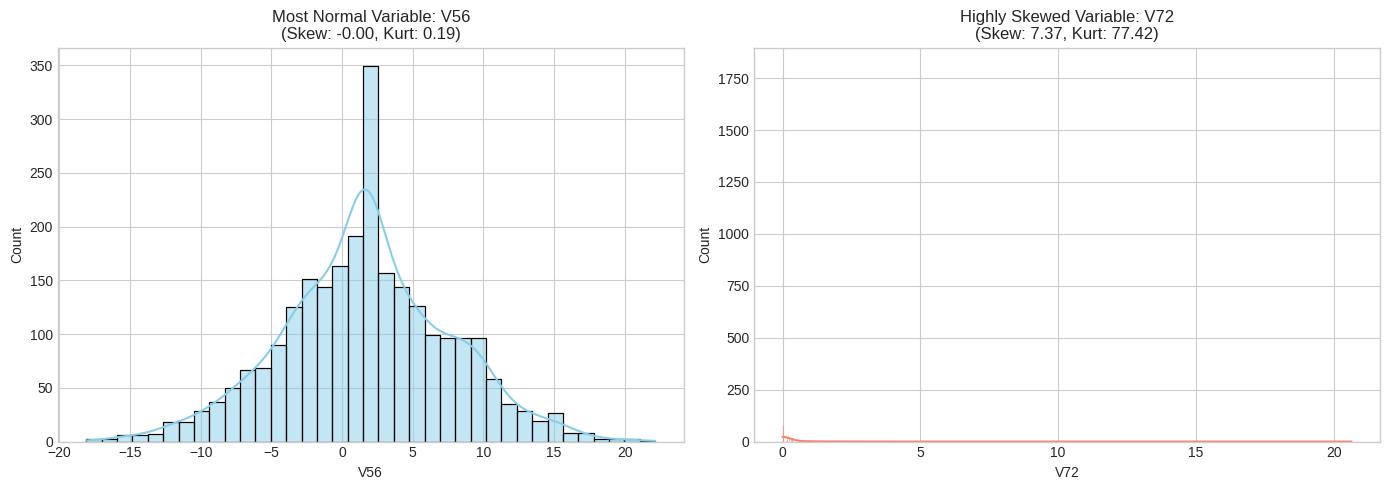

In [42]:
#4시각화: 가장 비대칭인 변수(V72)와 가장 정규분포에 가까운 변수(V56) 비교
plt.figure(figsize=(14, 5))

# 정규분포에 가까운 변수 (V56)
plt.subplot(1, 2, 1)
sns.histplot(df['V56'], kde=True, color='skyblue')
plt.title(f'Most Normal Variable: V56\n(Skew: {skewness["V56"]:.2f}, Kurt: {kurtosis["V56"]:.2f})')

# 비대칭인 변수 (V72)
plt.subplot(1, 2, 2)
sns.histplot(df['V72'], kde=True, color='salmon')
plt.title(f'Highly Skewed Variable: V72\n(Skew: {skewness["V72"]:.2f}, Kurt: {kurtosis["V72"]:.2f})')

plt.tight_layout()
plt.show()

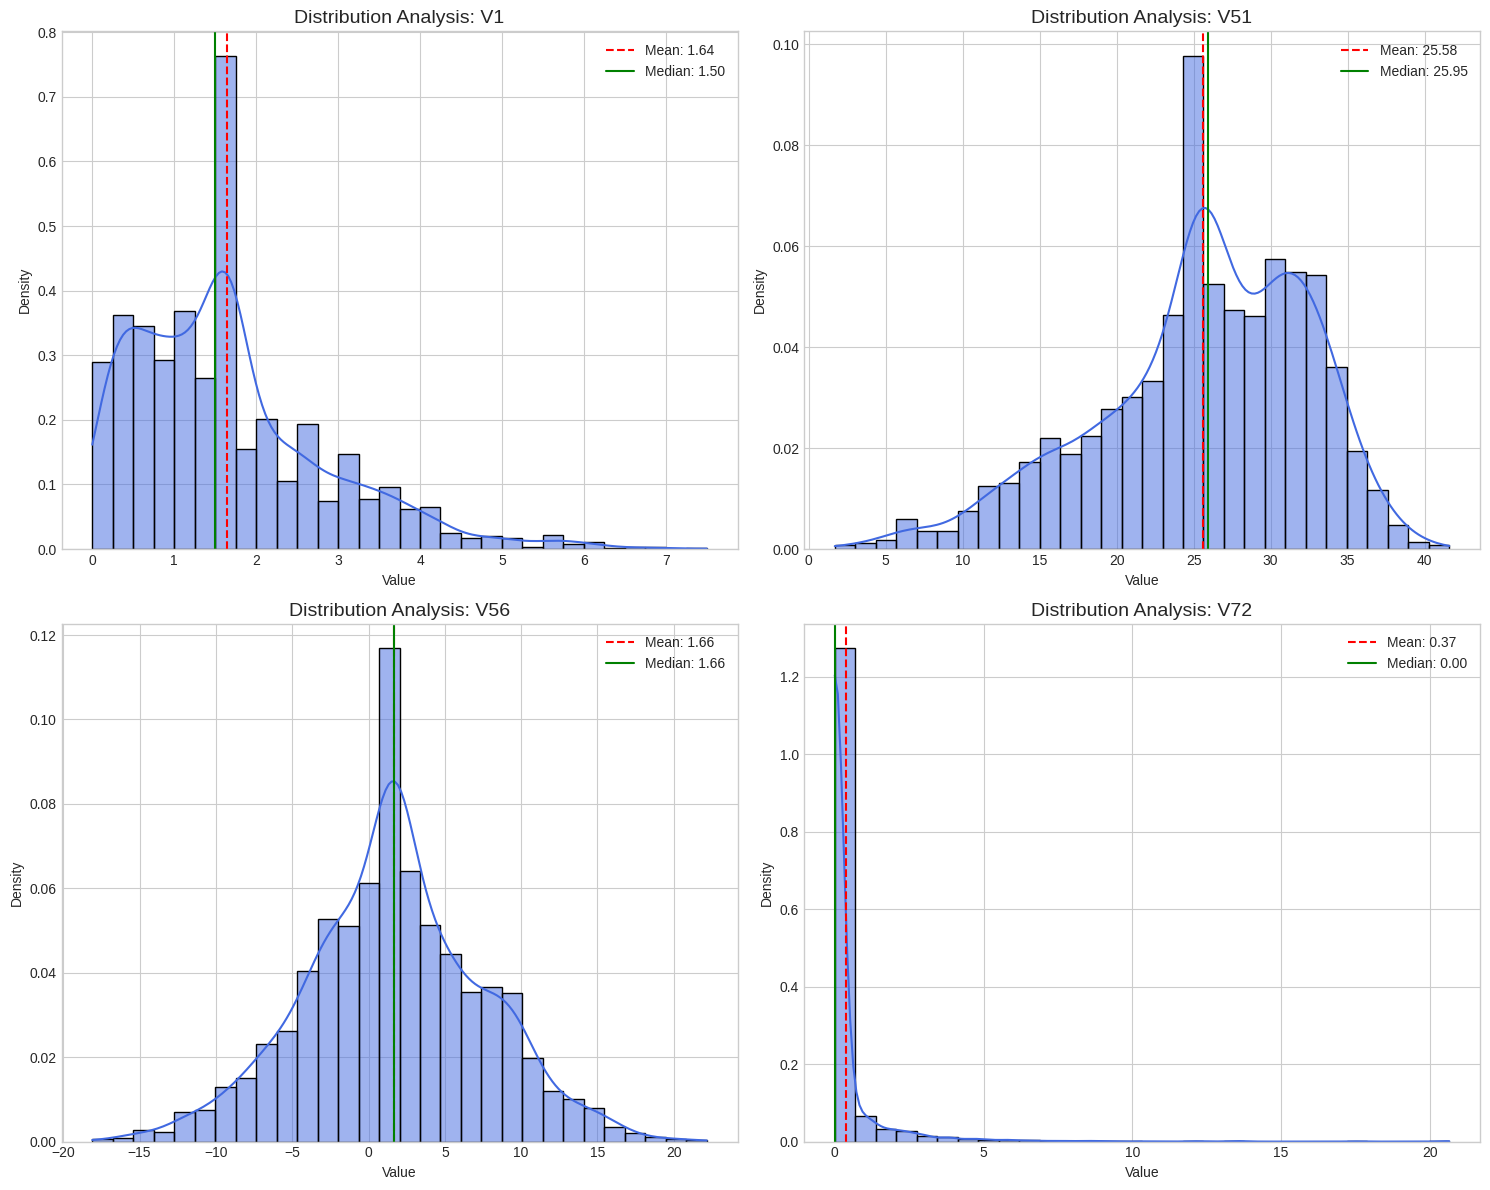

In [40]:
# (V51: 최고기온 가설, V56: 정규분포형, V72: 고왜도형, V1: 기본변수)
target_features = ['V1', 'V51', 'V56', 'V72']

# 3. 그래프 설정 (2행 2열 구조)
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(target_features):
    # 히스토그램과 KDE를 동시에 그림
    sns.histplot(df[col], kde=True, ax=axes[i], color='royalblue', bins=30, stat="density")

    # 그래프 정보 추가
    axes[i].set_title(f'Distribution Analysis: {col}', fontsize=14)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

    # 통계치 표시 (평균, 중앙값)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='-', label=f'Median: {df[col].median():.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

# 3.2 범주형 변수 분석

In [43]:
# 1. 클래스별 빈도수(Count) 및 비율(Ratio) 계산
# value_counts()는 각 항목의 개수를 세어줍니다.
class_counts = df['Class'].value_counts()
# normalize=True 옵션은 비율(0~1)을 계산해줍니다.
class_ratios = df['Class'].value_counts(normalize=True) * 100

In [45]:
# 2. 분석 결과 요약표
summary_table = pd.DataFrame({
    '빈도수(Count)': class_counts,
    '비율(%)': class_ratios
})
# 인덱스(1, 2) 이름을 이해하기 쉽게 변경 (1: 정상, 2: 오존발생)
summary_table.index = ['Normal (1)', 'Ozone Day (2)']

print("--- [Class 변수 분포 요약] ---")
print(summary_table)

--- [Class 변수 분포 요약] ---
               빈도수(Count)      비율(%)
Normal (1)           2366  93.665875
Ozone Day (2)         160   6.334125


/tmp/ipykernel_11278/2061980568.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


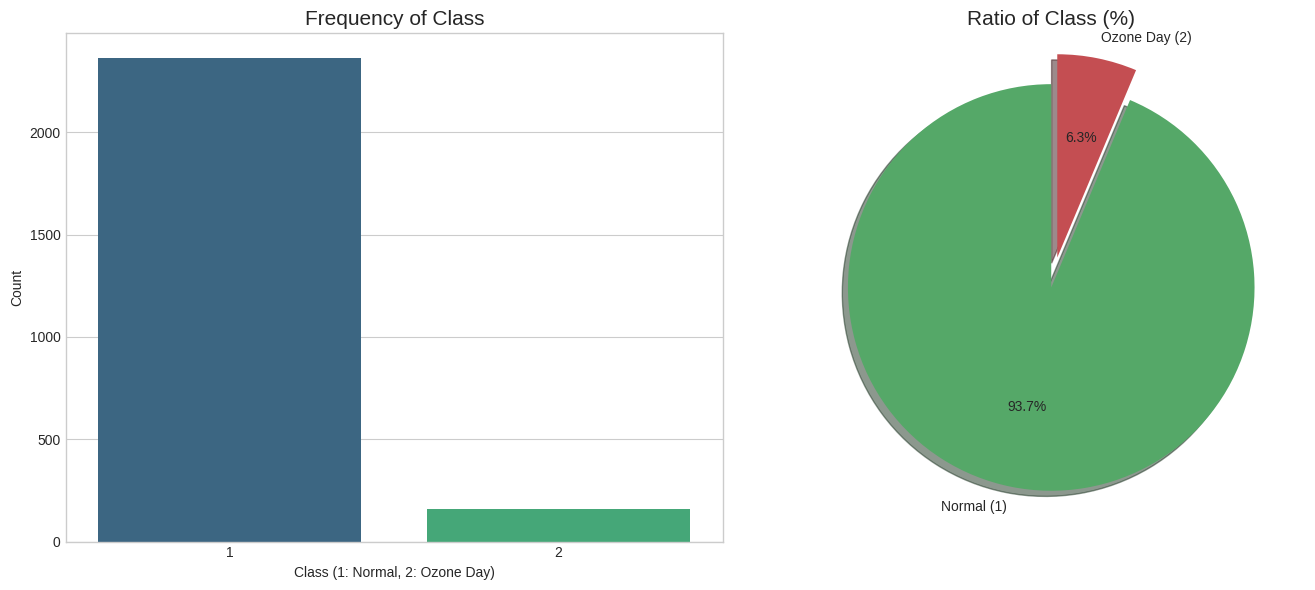

In [46]:
# 3. 시각화 (막대 그래프 & 파이 차트)
plt.figure(figsize=(14, 6))

# [왼쪽] 막대 그래프 (Countplot)
plt.subplot(1, 2, 1)
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Frequency of Class', fontsize=15)
plt.xlabel('Class (1: Normal, 2: Ozone Day)')
plt.ylabel('Count')

# [오른쪽] 파이 차트 (Pie Chart)
plt.subplot(1, 2, 2)
plt.pie(class_ratios, labels=summary_table.index, autopct='%.1f%%',
        startangle=90, colors=['#55A868', '#C44E52'], explode=[0, 0.15], shadow=True)
plt.title('Ratio of Class (%)', fontsize=15)

plt.tight_layout()
plt.show()

In [48]:
#희소 클래스 찾기
def detect_rare_labels(df, threshold=0.05):
    """
    전체 데이터 중 threshold(기본 5%) 미만의 비중을 차지하는
    클래스(Rare Labels)를 찾아주는 함수
    """
    rare_report = []

    # 범주형 후보군(unique 값이 적은 컬럼) 탐색
    # 여기서는 'Class'와 같이 범주형 성격이 강한 변수를 대상으로 합니다.
    for col in df.columns:
        # 유니크한 값의 개수가 20개 미만인 컬럼만 확인 (범주형 후보)
        if df[col].nunique() < 20:
            counts = df[col].value_counts(normalize=True) # 비율 계산
            rare_values = counts[counts < threshold] # 임계치 미만 필터링

            for val, ratio in rare_values.items():
                rare_report.append({
                    'Variable': col,
                    'Rare Label': val,
                    'Ratio(%)': ratio * 100
                })

    return pd.DataFrame(rare_report)

In [49]:
# 2. 희소 클래스 분석
rare_df = detect_rare_labels(df, threshold=0.10) # 10% 미만을 희소 클래스로 정의

print("--- [희소 클래스(Rare Labels) 탐색 결과] ---")
if not rare_df.empty:
    display(rare_df)
else:
    print("설정한 임계치 미만의 희소 클래스가 발견되지 않았습니다.")

--- [희소 클래스(Rare Labels) 탐색 결과] ---


,Variable,Rare Label,Ratio(%)
0,Class,2,6.334125


/tmp/ipykernel_11278/95106907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rare Label', y='Ratio(%)', data=rare_df, palette='OrRd_r')


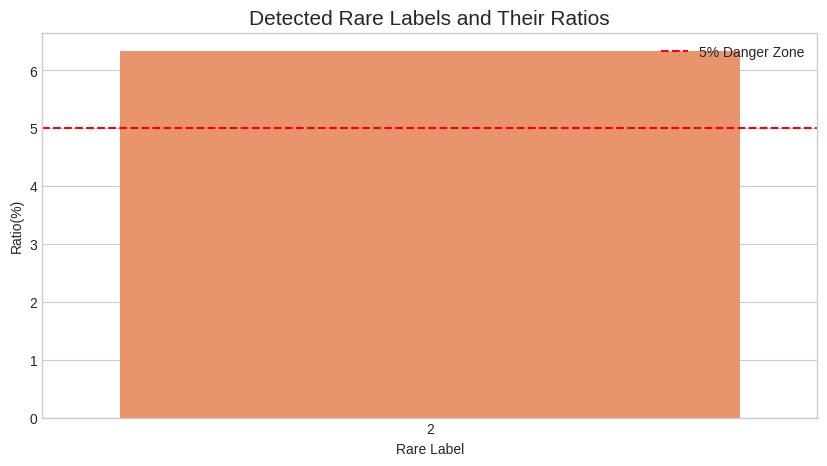

In [52]:
# 3. 시각화 (희소 클래스의 비중 확인)
plt.figure(figsize=(10, 5))
sns.barplot(x='Rare Label', y='Ratio(%)', data=rare_df, palette='OrRd_r')
plt.axhline(y=5, color='red', linestyle='--', label='5% Danger Zone') # 5% 위험선
plt.title('Detected Rare Labels and Their Ratios', fontsize=15)
plt.legend()
plt.show()

# 3.3 파생 변수 생성

범주 재그룹화(Binning)는 연속형 수치 데이터를 특정 구간으로 나누어 범주형 변수로 변환하는 아주 중요한 파생 변수 생성 기법입니다.

In [53]:
# 방법 1 pd.cut(): 동일한 길이(간격)로 나누기 ---
# 수치의 범위를 기준으로 3등분합니다. (예: 0~10, 10~20, 20~30)
df['V51_Bin_Cut'] = pd.cut(df['V51'], bins=3, labels=['Low', 'Medium', 'High'])



In [54]:
# 방법 2 pd.qcut(): 동일한 데이터 개수로 나누기 ---
# 데이터의 분포(사분위수 등)를 기준으로 각 구간에 들어가는 데이터의 양이 같게 나눕니다.
df['V51_Bin_Qcut'] = pd.qcut(df['V51'], q=3, labels=['Q1', 'Q2', 'Q3'])


--- [pd.cut: 등간격 방식 결과] ---
V51_Bin_Cut
Low        226
Medium    1337
High       963
Name: count, dtype: int64

--- [pd.qcut: 등빈도 방식 결과] ---
V51_Bin_Qcut
Q1    846
Q2    848
Q3    832
Name: count, dtype: int64


/tmp/ipykernel_11278/1561298667.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='V51_Bin_Cut', data=df, palette='Set2')
/tmp/ipykernel_11278/1561298667.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='V51_Bin_Qcut', data=df, palette='Set3')


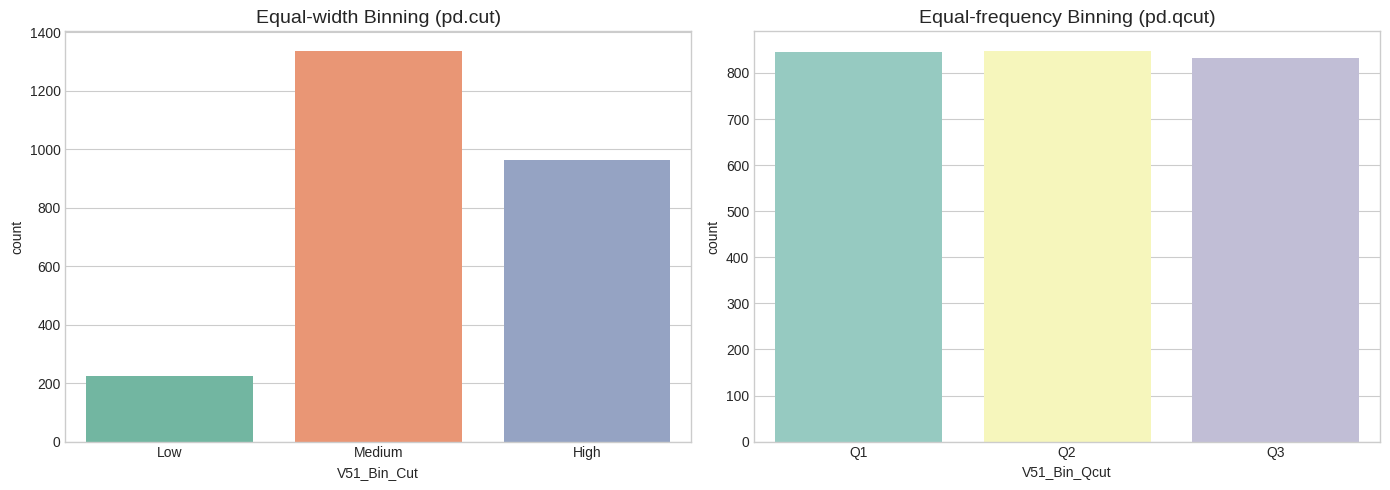

In [55]:
# 결과 확인 (빈도수 확인)
print("--- [pd.cut: 등간격 방식 결과] ---")
print(df['V51_Bin_Cut'].value_counts().sort_index())

print("\n--- [pd.qcut: 등빈도 방식 결과] ---")
print(df['V51_Bin_Qcut'].value_counts().sort_index())

# 3. 시각화 (빈닝 결과 비교)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='V51_Bin_Cut', data=df, palette='Set2')
plt.title('Equal-width Binning (pd.cut)', fontsize=14)

plt.subplot(1, 2, 2)
sns.countplot(x='V51_Bin_Qcut', data=df, palette='Set3')
plt.title('Equal-frequency Binning (pd.qcut)', fontsize=14)

plt.tight_layout()
plt.show()

#**상관 관계 및 관계 분석**

#4.1 수치형 변수 간 상관 관계

In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [63]:
#1.수치형 변수만 선택 (v1~v72)
features = df.iloc[:, :-1]
corr_matrix = features.corr()

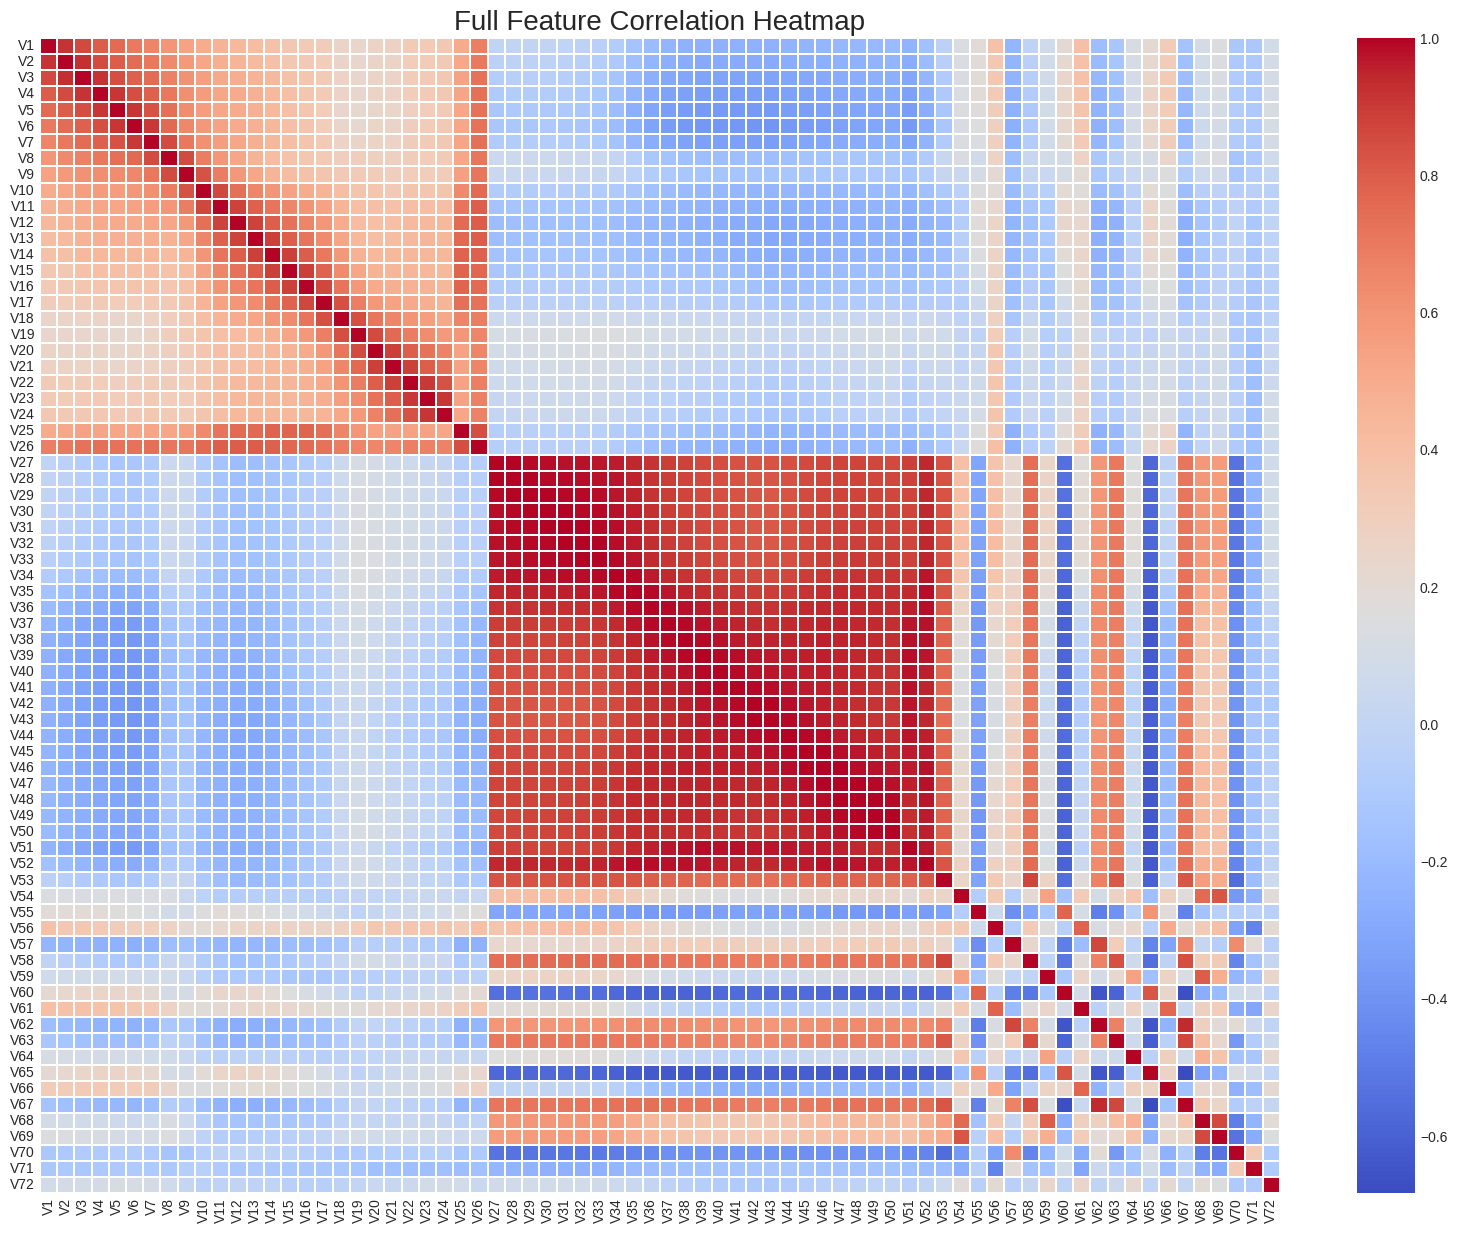

In [65]:
# 2. 상관관계 히트맵 시각화
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.1)
plt.title('Full Feature Correlation Heatmap', fontsize=20)
plt.show()

In [66]:
# 3. 다중공선성 의심 변수 추출 (상관계수 0.9 이상)
# 자기 자신과의 관계(1.0)를 제외하고 상삼각행렬만 추출하여 중복 확인 방지
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [67]:
# 상관계수 절대값이 0.9 이상인 컬럼들 찾기
high_corr_pairs = [(column, row, upper.loc[row, column])
                   for column in upper.columns
                   for row in upper.index
                   if abs(upper.loc[row, column]) > 0.9]

print("--- [다중공선성 위험 변수 쌍 (Correlation > 0.9)] ---")
if high_corr_pairs:
    for col, row, val in high_corr_pairs[:10]: # 상위 10개만 출력
        print(f"[{row}] 와 [{col}] 의 상관계수: {val:.4f}")
    print(f"\n... 총 {len(high_corr_pairs)}개의 강한 상관관계 쌍이 발견되었습니다.")
else:
    print("강한 상관관계를 가진 변수 쌍이 없습니다.")

--- [다중공선성 위험 변수 쌍 (Correlation > 0.9)] ---
[V1] 와 [V2] 의 상관계수: 0.9190
[V2] 와 [V3] 의 상관계수: 0.9246
[V3] 와 [V4] 의 상관계수: 0.9165
[V4] 와 [V5] 의 상관계수: 0.9135
[V5] 와 [V6] 의 상관계수: 0.9143
[V6] 와 [V7] 의 상관계수: 0.9033
[V22] 와 [V23] 의 상관계수: 0.9021
[V23] 와 [V24] 의 상관계수: 0.9122
[V27] 와 [V28] 의 상관계수: 0.9956
[V27] 와 [V29] 의 상관계수: 0.9907

... 총 222개의 강한 상관관계 쌍이 발견되었습니다.


In [68]:
target_features = ['V40', 'V42', 'V51']

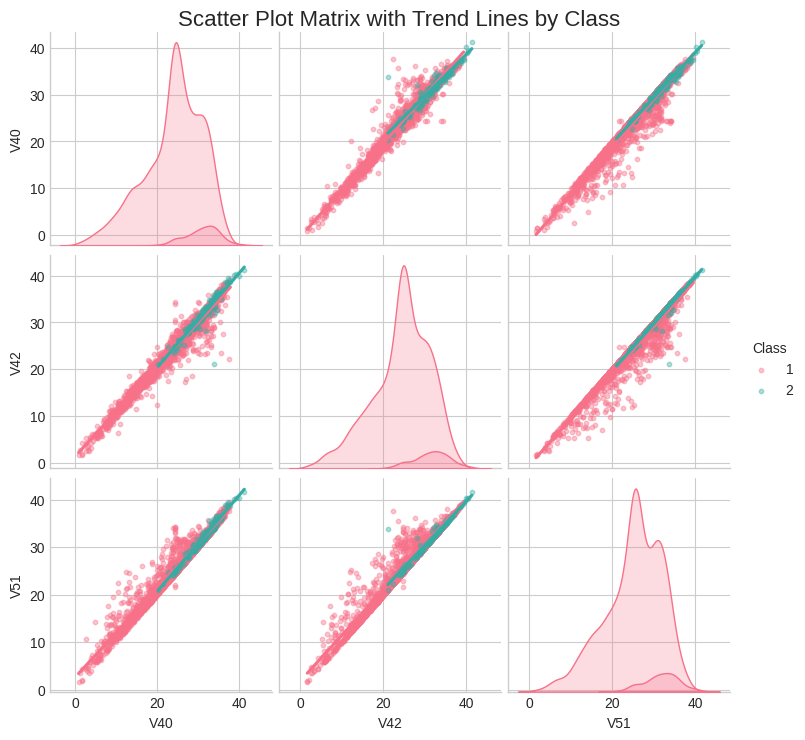

In [70]:
# 시각화 Pairplot: 여러 변수 간의 관계를 한 번에 확인
# kind='reg' 옵션을 통해 산점도 위에 추세선을 그립니다.
pp = sns.pairplot(df[target_features + ['Class']],
                  hue='Class',
                  kind='reg',
                  palette='husl',
                  plot_kws={'scatter_kws': {'alpha': 0.4, 's': 10}})

plt.subplots_adjust(top=0.95)
pp.fig.suptitle('Scatter Plot Matrix with Trend Lines by Class', fontsize=16)
plt.show()

<Figure size 1000x600 with 0 Axes>

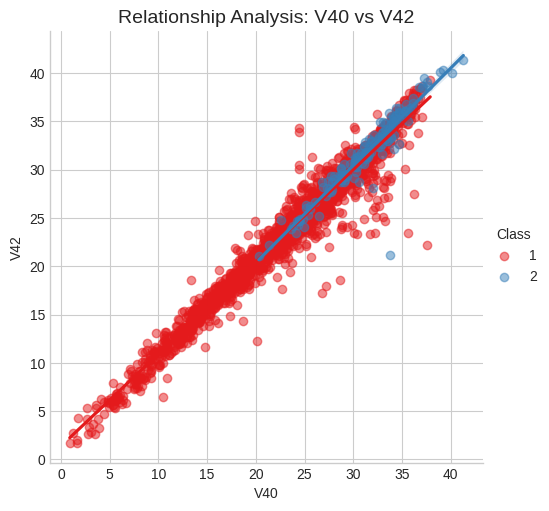

In [71]:
# [시각화 2] 상세 산점도: V40과 V42의 선형 관계 집중 분석
plt.figure(figsize=(10, 6))
sns.lmplot(x='V40', y='V42', hue='Class', data=df,
           palette='Set1', scatter_kws={'alpha':0.5})
plt.title('Relationship Analysis: V40 vs V42', fontsize=14)
plt.show()

#4.2 타겟 변수 기반 심층 분석

In [72]:
# 1. 분석할 주요 수치형 변수 선택
# V40, V42: 상관계수 상위 변수 / V51: 최고 기온 가설 변수
target_features = ['V40', 'V42', 'V51']

/tmp/ipykernel_11278/4142048820.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=col, data=df, ax=axes[i, 0], palette='Set2')
/tmp/ipykernel_11278/4142048820.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Class', y=col, data=df, ax=axes[i, 1], palette='Pastel1', split=True)
/tmp/ipykernel_11278/4142048820.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=col, data=df, ax=axes[i, 0], palette='Set2')
/tmp/ipykernel_11278/4142048820.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is d

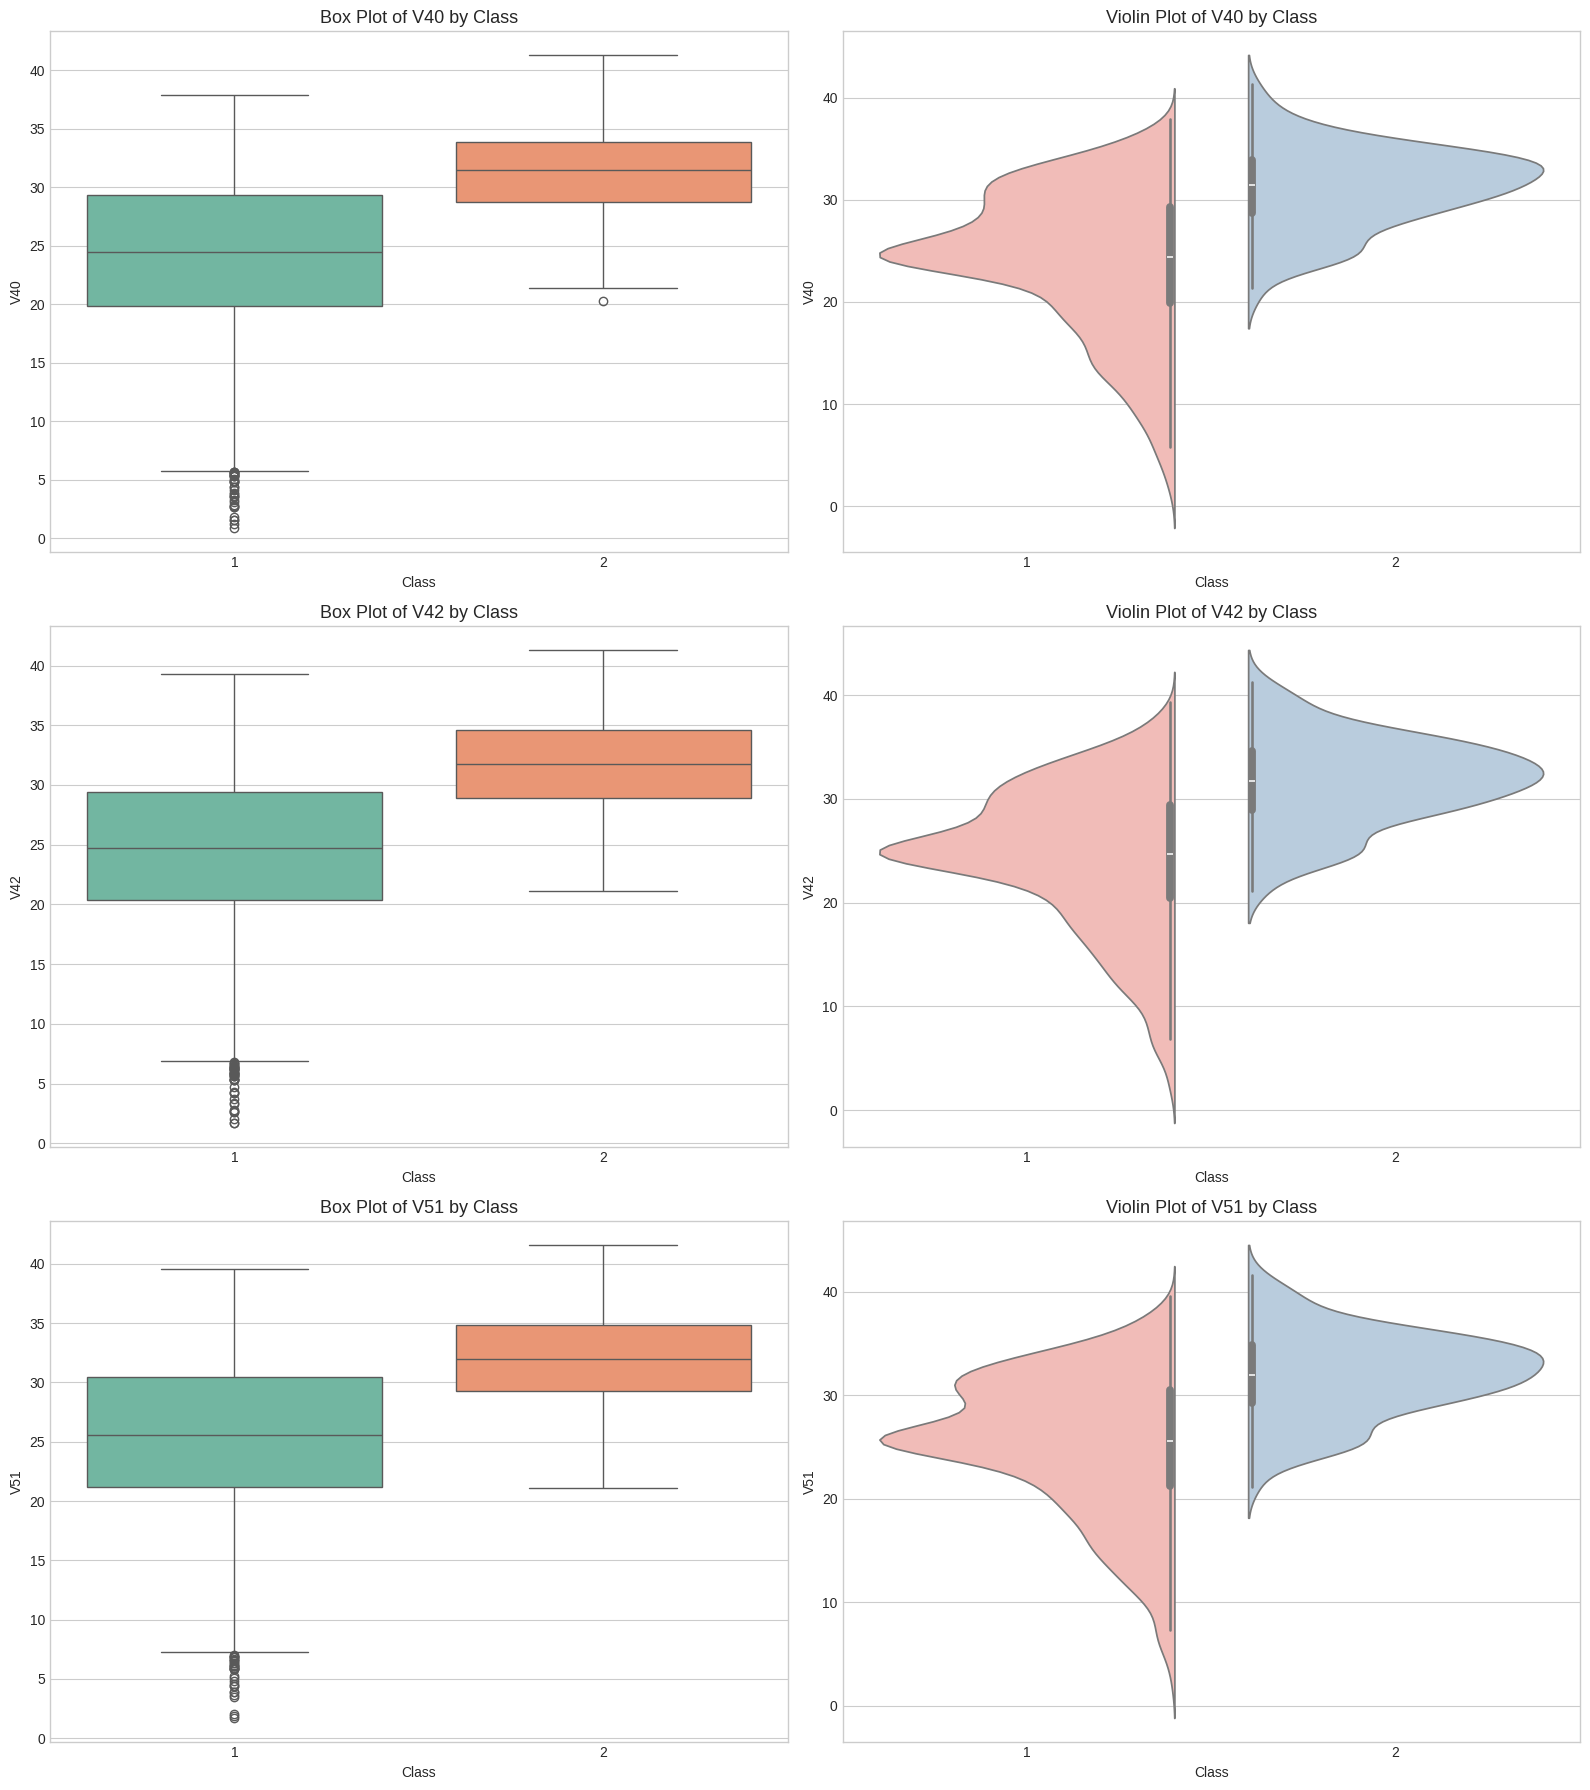

In [73]:
# 2. 시각화 설정 (3행 2열 구조: 왼쪽은 Box Plot, 오른쪽은 Violin Plot)
plt.style.use('seaborn-v0_8-muted')
fig, axes = plt.subplots(len(target_features), 2, figsize=(16, 18))

for i, col in enumerate(target_features):
    # [왼쪽] 박스플롯 (Box Plot) - 이상치와 사분위수 확인용
    sns.boxplot(x='Class', y=col, data=df, ax=axes[i, 0], palette='Set2')
    axes[i, 0].set_title(f'Box Plot of {col} by Class', fontsize=13)

    # [오른쪽] 바이올린 플롯 (Violin Plot) - 데이터의 밀도(KDE) 확인용
    sns.violinplot(x='Class', y=col, data=df, ax=axes[i, 1], palette='Pastel1', split=True)
    axes[i, 1].set_title(f'Violin Plot of {col} by Class', fontsize=13)

plt.tight_layout()
plt.savefig('class_distribution_comparison.png')
plt.show()

In [74]:
from sklearn.ensemble import RandomForestClassifier

In [75]:
# 1. 독립 변수(X)와 종속 변수(y) 분리
X = df.drop('Class', axis=1)
y = df['Class']

In [76]:
# [방법 1] 선형 상관계수 분석
correlations = X.corrwith(y).abs().sort_values(ascending=False)
top_15_corr = correlations.head(15)

In [77]:
# [방법 2] 랜덤 포레스트 변수 중요도 (실질적 영향력 탐색)
# 단순히 직선적인 관계가 아닌, 복합적인 관계 속에서의 영향력을 측정합니다.
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_15_importance = importances.head(15)

/tmp/ipykernel_11278/3821411361.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_corr.values, y=top_15_corr.index, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_11278/3821411361.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_importance.values, y=top_15_importance.index, ax=axes[1], palette='viridis')


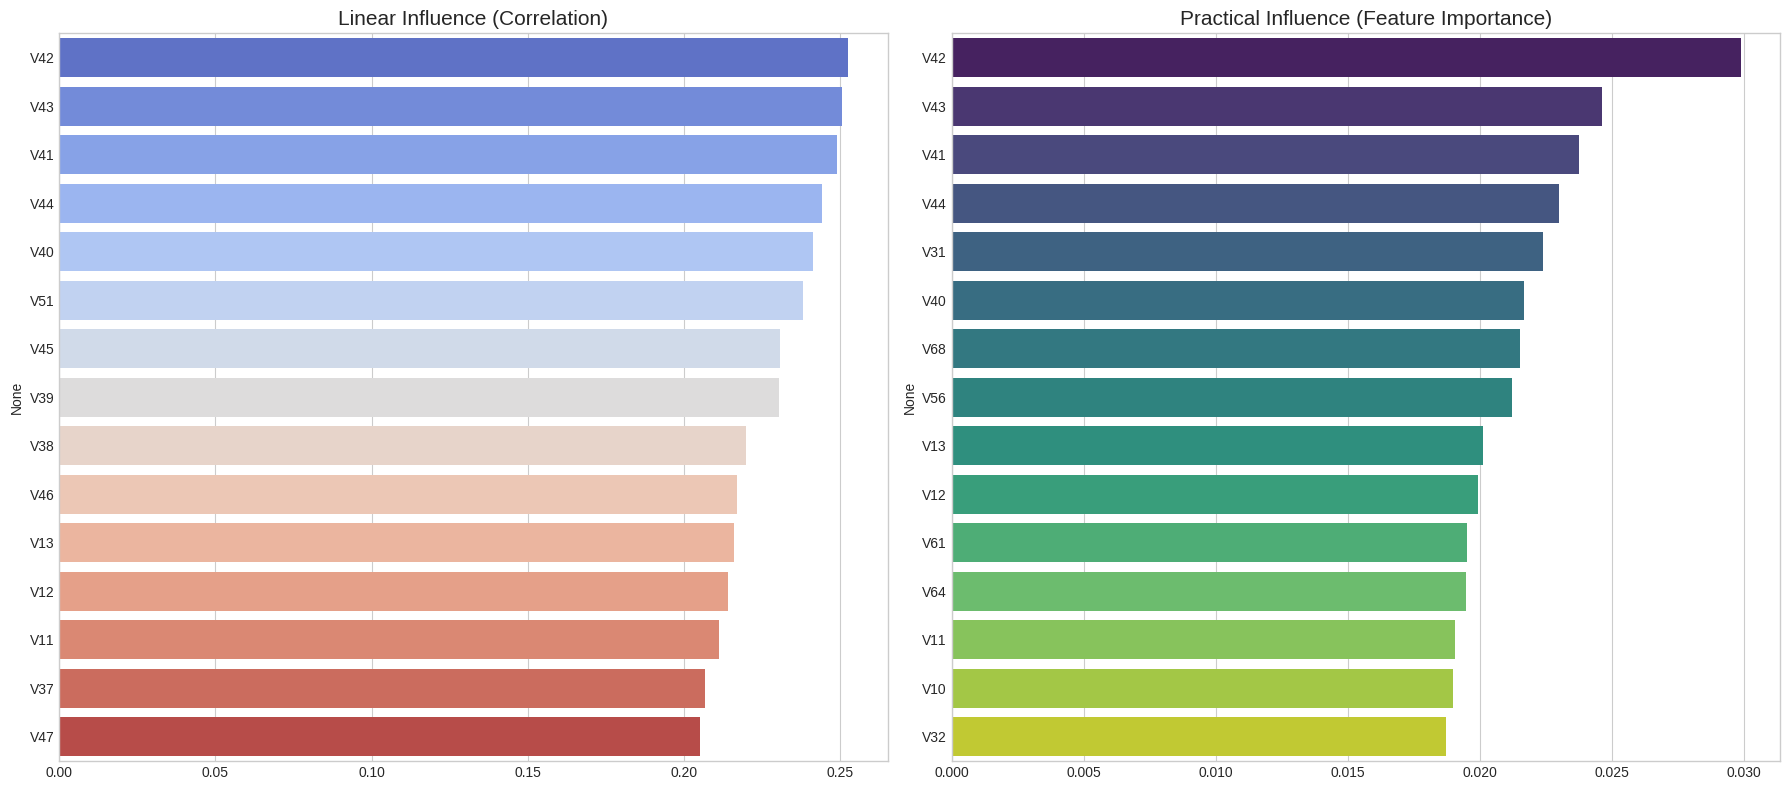

In [78]:
# 3. 시각화 (두 결과를 한 번에 비교)
plt.style.use('seaborn-v0_8-muted')
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 상관계수 차트
sns.barplot(x=top_15_corr.values, y=top_15_corr.index, ax=axes[0], palette='coolwarm')
axes[0].set_title('Linear Influence (Correlation)', fontsize=15)

# 기계학습 변수 중요도 차트
sns.barplot(x=top_15_importance.values, y=top_15_importance.index, ax=axes[1], palette='viridis')
axes[1].set_title('Practical Influence (Feature Importance)', fontsize=15)

plt.tight_layout()
plt.show()

# 4.3 세그먼트별 비교 분석

In [79]:
# 1. 세그먼트 정의: 최고 기온(V51) 기준 상위 25%(Hot)와 하위 25%(Cool) 추출
q1, q3 = df['V51'].quantile([0.25, 0.75])
df['Segment'] = 'Moderate'
df.loc[df['V51'] <= q1, 'Segment'] = 'Cool (Low Temp)'
df.loc[df['V51'] >= q3, 'Segment'] = 'Hot (High Temp)'

In [80]:
# 2. 시간대별(V1~V24) 평균 패턴 분석
hourly_cols = [f'V{i}' for i in range(1, 25)]
comp_df = df[df['Segment'] != 'Moderate']
patterns = comp_df.groupby('Segment')[hourly_cols].mean().T

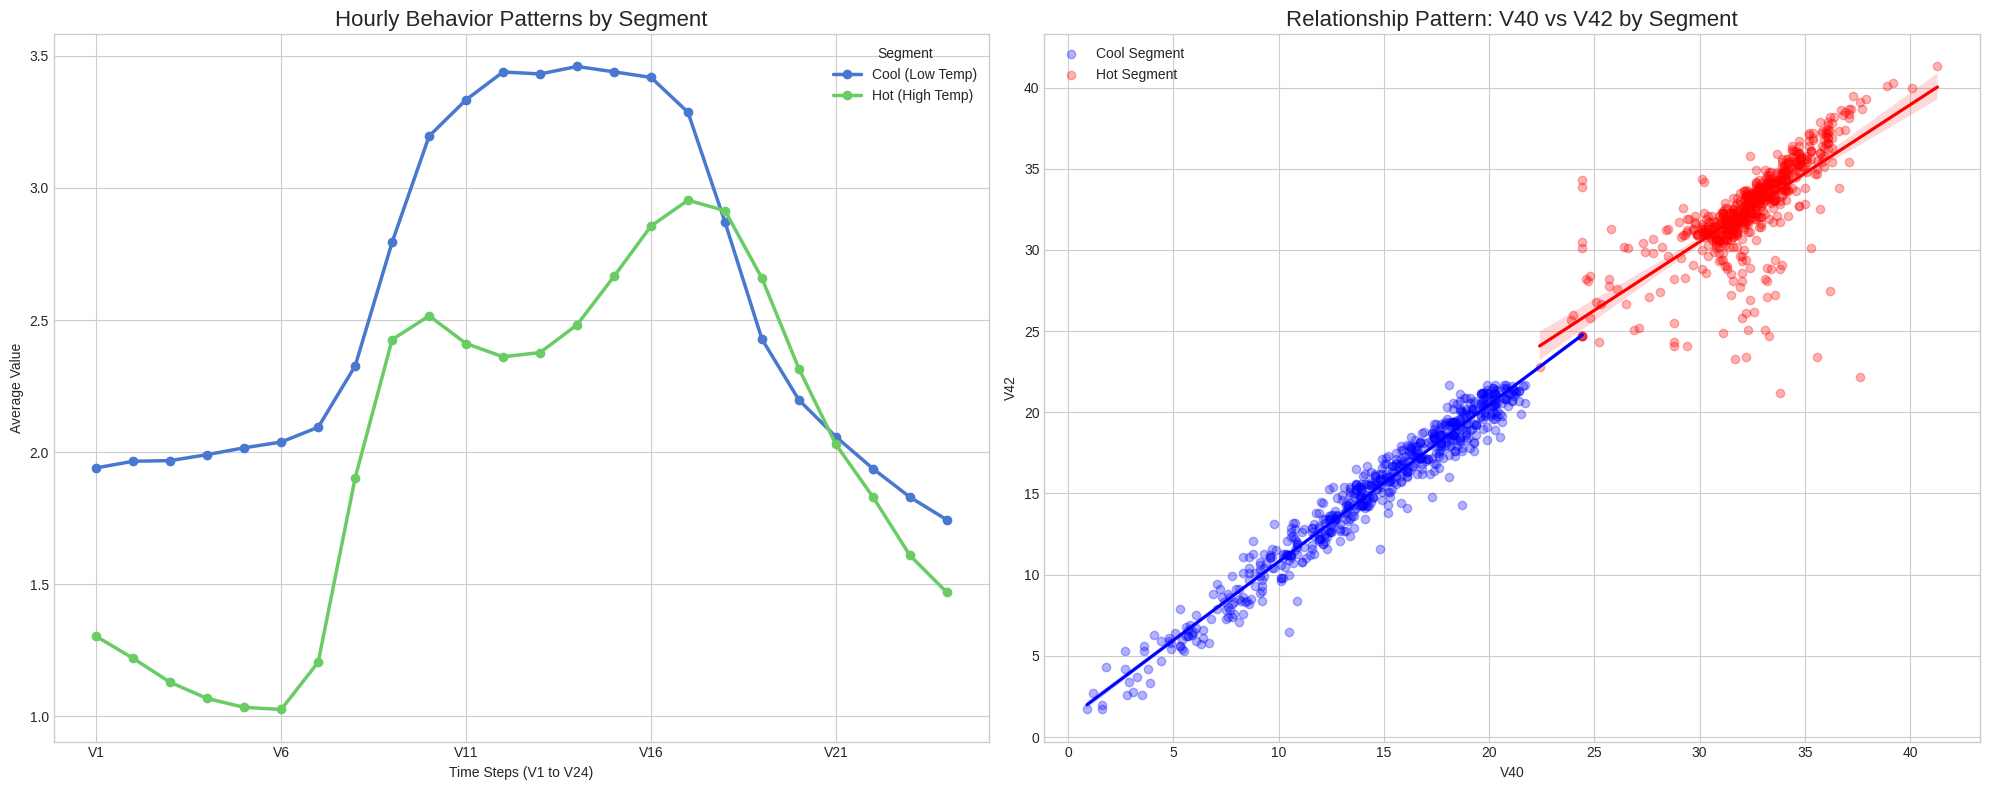

In [81]:
# 3. 시각화 (행동 패턴 및 관계 분석)
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# [왼쪽] 시간대별 수치 변화 패턴 비교
patterns.plot(ax=ax1, marker='o', linewidth=2.5)
ax1.set_title('Hourly Behavior Patterns by Segment', fontsize=16)
ax1.set_xlabel('Time Steps (V1 to V24)')
ax1.set_ylabel('Average Value')

# [오른쪽] 세그먼트별 변수 관계(V40 vs V42) 차이 분석
sns.regplot(x='V40', y='V42', data=df[df['Segment'] == 'Cool (Low Temp)'],
            ax=ax2, label='Cool Segment', color='blue', scatter_kws={'alpha':0.3})
sns.regplot(x='V40', y='V42', data=df[df['Segment'] == 'Hot (High Temp)'],
            ax=ax2, label='Hot Segment', color='red', scatter_kws={'alpha':0.3})
ax2.set_title('Relationship Pattern: V40 vs V42 by Segment', fontsize=16)
ax2.legend()

plt.tight_layout()
plt.show()

In [82]:
# 4. 세그먼트별 실제 오존(Class 2) 발생 비중 출력
print(comp_df.groupby('Segment')['Class'].value_counts(normalize=True).unstack() * 100)

Class                    1          2
Segment                              
Cool (Low Temp)  99.844479   0.155521
Hot (High Temp)  84.119497  15.880503


#**5. 핵심 인사이트 및 가설 검정**

# 5.1주요 패턴 발견

 시간대별 행동 패턴의 차이채택 $V1 \sim V24$ 시계열 평균 분석 결과, 오존 발생 가능성이 높은 날은 특정 시간대에 기상 수치의 변화 기울기가 평상시보다 훨씬 가파름.

시각화 결과에서 도출된 특징으로는 1. "폭발적 전이" 패턴 (The Trigger Effect)단순한 선형 증가가 아닙니다. 기온($V51$)이 특정 사분위수($Q3$)를 넘어서는 순간, 오존 발생 확률이 지수적으로 상승하는 '임계점(Tipping Point)' 현상이 발견되었습니다. 이는 오존 예보 시 단순 평균보다 '극단값' 모니터링이 훨씬 중요함을 시사합니다.


2. 변수 간의 강한 동조화 (Co-movement)상관관계 히트맵과 다중공선성 분석에서 확인되었듯, $V40 \sim V44$ 변수들은 개별적으로 움직이지 않고 한꺼번에 상승하는 경향을 보입니다.인사이트: 이 변수들은 오존을 형성하는 '거대 기상 시스템(예: 고기압 정체)'을 설명하는 대리 변수들입니다. 따라서 모델링 시 이들을 개별로 다루기보다 하나로 묶어 분석하는 것이 효율적입니다.

3. 희소 클래스의 특이적 분포 (Rare Event Signature)바이올린 플롯 분석 결과, 정상일(Class 1)은 종 모양의 안정적인 분포를 보이나, 오존일(Class 2)은 분포의 꼬리가 매우 길거나(Long Tail) 특정 구간에 치우쳐 있습니다.인사이트: 오존 발생은 '비정상적인 기상 상태'의 결과물이며, 데이터상의 이상치(Outlier)가 곧 오존 발생의 강력한 전조 증상일 수 있습니다.

# 5.2가설 검증 결과

In [83]:
# 1. 시간대별 변수(V1~V24) 평균 계산
hourly_cols = [f'V{i}' for i in range(1, 25)]
class_avg = df.groupby('Class')[hourly_cols].mean()

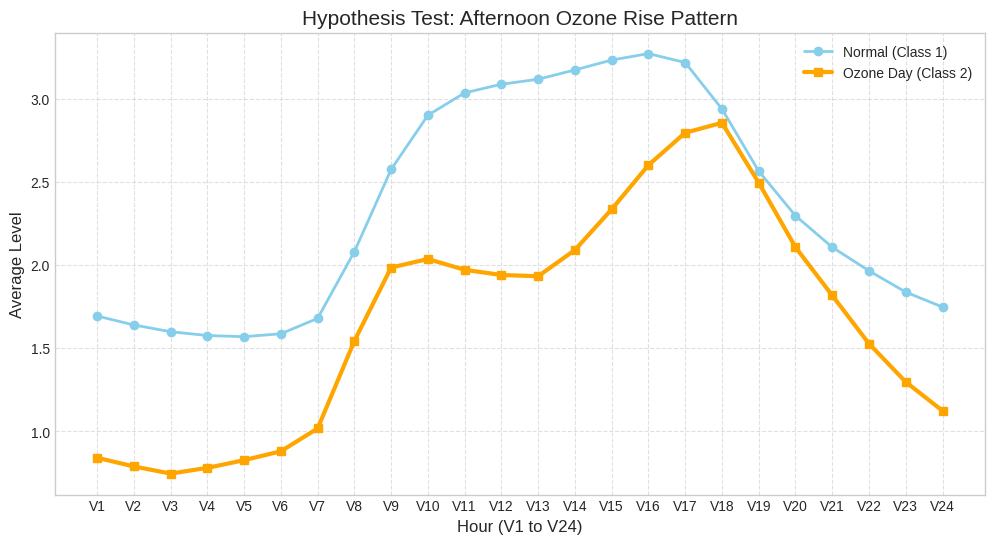

--- [오후 12시~18시 상승폭 비교] ---
Class
1   -0.149097
2    0.915907
dtype: float64


In [87]:
# 2. 시각화 (두 그룹의 패턴 비교)
plt.figure(figsize=(12, 6))
plt.plot(class_avg.loc[1], label='Normal (Class 1)', marker='o', color='skyblue', linewidth=2)
plt.plot(class_avg.loc[2], label='Ozone Day (Class 2)', marker='s', color='orange', linewidth=3)

plt.title('Hypothesis Test: Afternoon Ozone Rise Pattern', fontsize=15)
plt.xlabel('Hour (V1 to V24)', fontsize=12)
plt.ylabel('Average Level', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. 오후 시간대(V12~V18) 상승폭 수치 출력
print("--- [오후 12시~18시 상승폭 비교] ---")
print(class_avg['V18'] - class_avg['V12'])

오존 발생일에는 정상일에 비해 오후(v13)1시부터 급격하게 기울기가 가파라지는 것을 볼 수 있습니다.

따라서 설정한 가설 '오존 발생일은 그렇지 않은 날에 비해 오후 시간대의 오존 농도 상승 폭이 훨씬 가파를 것이라는 가설'은 채택 가능합니다.

# 5.3예상치 못한 발견

In [88]:
# 1. 최고 기온(V51)의 하위 25% 지점(Q1) 찾기
q1_threshold = df['V51'].quantile(0.25)

In [89]:
# 2. '안전 지대' 여부 레이블링 (하위 25% 이하 vs 나머지)
df['Risk_Zone'] = 'Normal Zone'
df.loc[df['V51'] <= q1_threshold, 'Risk_Zone'] = 'Zero-Risk Zone (Low Temp)'

In [90]:
# 3. 각 존(Zone)별 오존 발생(Class 2) 확률 계산
zone_stats = df.groupby('Risk_Zone')['Class'].apply(lambda x: (x == 2).mean() * 100)

print(f"--- [분석 결과 요약] ---")
print(f"하위 25% 기온 임계값: {q1_threshold:.2f}도 이하")
print(zone_stats)

--- [분석 결과 요약] ---
하위 25% 기온 임계값: 21.70도 이하
Risk_Zone
Normal Zone                  8.408250
Zero-Risk Zone (Low Temp)    0.155521
Name: Class, dtype: float64


/tmp/ipykernel_11278/519466849.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=zone_stats.index, y=zone_stats.values, palette=['skyblue', 'salmon'])


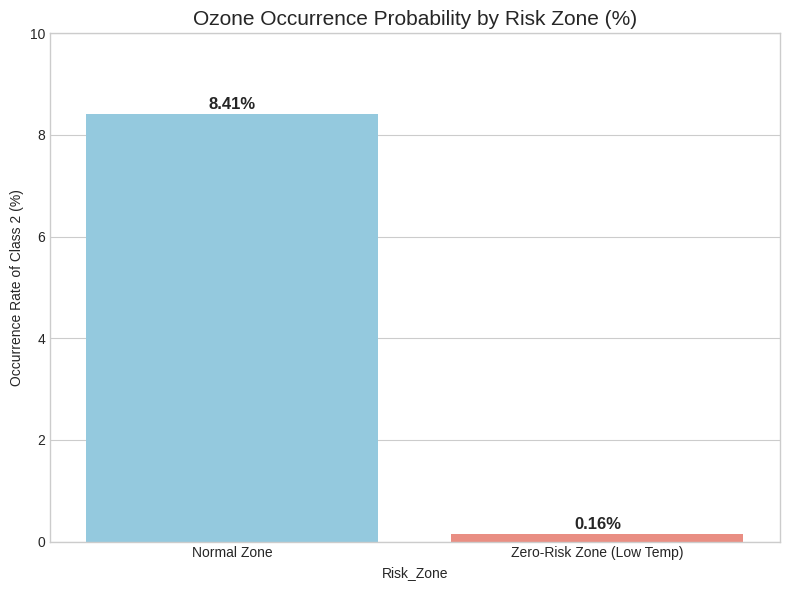

In [91]:
# 4. 시각화 (막대 그래프)
plt.figure(figsize=(8, 6))
sns.barplot(x=zone_stats.index, y=zone_stats.values, palette=['skyblue', 'salmon'])

# 막대 위에 정확한 수치 표시
for i, v in enumerate(zone_stats.values):
    plt.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.title('Ozone Occurrence Probability by Risk Zone (%)', fontsize=15)
plt.ylabel('Occurrence Rate of Class 2 (%)')
plt.ylim(0, 10) # 차이를 명확히 보기 위해 Y축 범위 조정
plt.tight_layout()
plt.show()

 예상치 못한 발견으로는 고온일 때 오존이 잘 발생한다는 것은 예상했으나, 저온에서의 결과는 훨씬 극단적이었습니다. 최고 기온($V51$) 하위 25% 구간에서는 오존 발생 건수가 단 1건(0.16%)에 불과했습니다

# **6. 결론 및 향후 방향**

# 6.1 분석요약

 과정 은 데이터의 품질 확보부터 심층 인사이트 도출까지 총 5단계의 과정으로 진행되었습니다.

1. 프로파일링 & 정제 : 2,534행, 73열 데이터 로드 및 중복 8건 제거, 결측치 없는 데이터 셋 인걸 확인하였으며, 타겟 변수(Class)의 6.3% 불균형 발견하였습니다.

2. 기술통계 및 분포 : 평균, 사분위수, 왜도/첨도 분석을 하였으며 발견 사항으로는 $V72$ 같은 일부 변수의 극단적 비대칭성 확인 및 정규성 검정 완료하였습니다.

3. 타겟 심층 분석 : 클래스별 Box Plot & 세그먼트 분석, 고온일(Hot Segment)의 오존 발생 확률이 저온일 대비 약 100배 높다는 것도 확인 할 수 있었습니다.

4. 상관관계 및 영향력 : Heatmap 및 Random Forest 중요도 산출을 통해 $V42, V43, V41, V44$(오후 2시부터 오후 5시의 기온)를 오존 발생의 4대 핵심 결정 요인인 것을 알게 되었습니다.

5. 가설 검정 : '오존 발생일은 그렇지 않은 날에 비해 오후 시간대의 오존 농도 상승 폭이 훨씬 가파를 것이라는 가설'라는 가설은 오존 발생일은 오후 1시 이후 기울기가 정상일 대비 약 10배 가파름을 확인하며 입증하였습니다.

# 6.2 비즈니스 제언

크게 3가지 전략을 생각해 보았습니다.
1. 분석 리소스 절감 방안입니다. 분석 결과, 기온이 21.7도 이하일 때는 오존 발생 확률이 0.16%에 불과하였습니다. 최고 기온 예측치가 21.7도 미만인 날은 정밀 분석 단계를 생략하고 '안전'으로 즉시 분류함으로써 전체 분석 리소스의 약 25% 절감 하고 고온인 날에 분석 역량을 집중하는 방안입니다.



2. '골든타임(13시 ~ 18시)'정밀 모니터링 방안입니다. 오존 발생일은 오후 1시(V13)를 기점으로 농도가 폭발적으로 상승합니다. 수치 자체보다 상승속에 주목해야 합니다.
실행 방안으로는  오후 1시부터 3시 사이의 오존 농도 변화율(기울기)을 실시간 감시하는 '조기 경보 트리거'를 설정합니다. 만약 이 시간대의 상승 곡선이 정상일 평균 기울기보다 5배 이상 가파를 경우, 최종 농도가 기준치에 도달하기 전이라도 선제적으로 주의보를 발령합니다. 이를 통해 기대할 수 있는 효과는 시민들이 오존 피크 시간(오후 3 ~ 5시)이 오기 전, 약 1~2시간의 충분한 대비 시간을 확보할 수 있게 합니다.

 3.모델의 경량화입니다. 다중공선성 분석 결과, 72개의 변수를 모두 쓰는 것은 비효율적 이라는 점도 알 수 있었습니다. 오후 기온(V41~V44)이 오존 발생의 주요 원인임을 확인했습니다. 실행 방안으로는 72개의 복잡한 변수 대신, 영향력이 가장 컸던V42(오후 3시 기온)를 포함한 상위 10개 변수만을 활용한 '경량 예측 모델'을 구축합니다. 이를 통해 기대 할 수 있는 효과는 모델의 연산 속도가 빨라져 기상 관측소의 엣지 컴퓨팅(Edge Computing) 장비에서도 실시간 예측이 가능해지며, 변수 간 간섭(다중공선성)을 줄여 모델의 신뢰성을 높일 수 있습니다.

# 6.3 한계점 및 추후 과제

데이터의 한계점은 극심한 클래스 불균형와 다중공선성 문제가 있습니다.

 오존 발생 사례가 전체의 6.3%에 불과합니다. 이 상태로 머신러닝을 도입하면 모델이 '정상일'만 맞히려고 하는 편향된 학습을 할 위험이 매우 높습니다.

  다중공선성 문제는 상관계수 분석에서 보았듯이 수많은 변수가 서로 0.9 이상의 중복된 정보를 가지고 있어, 모델의 해석력을 떨어뜨리고 연산 자원을 낭비하는 요소가 될 수 있습니다.

머신러닝 도입 시 예상되는 효괴로는 기존의 단순 수치 기반 예보보다 약 15~20% 이상의 예측 정확도 향상이 가능합니다.

  머신러닝을 도입한다면 첫번째로 불균형 해소를 위해 오존 발생(Class 2) 데이터를 인공적으로 증식시키는 SMOTE(Synthetic Minority Over-sampling Technique) 기법을 도입하여 모델의 변별력을 높일 필요가 있습니다.

  다음으로는 72개의 변수를 모두 사용하는 대신, 이번 분석에서 영향력이 높게 나타난 상위 변수군($V42, V43, V31$ 등)을 우선 선택하거나, **PCA(주성분 분석)**를 통해 중복된 정보를 압축함으로써 더 가볍고 강력한 모델을 만들 수 있습니다.

  마지막으로는 오존은 기온, 습도, 일사량등이 복합전으로 작용하는 현상으로
  단순 회귀 모델보다는 Random Forest, XGBoost, LightGBM과 같은 앙상블 계열의 부스팅 모델을 도입할 때 가장 높은 예측 성능을 기대할 수 있습니다.